<a href="https://colab.research.google.com/github/peculab/DFTDescriptorPipeline/blob/main/examples/indigo_diaryl/indigo_diaryl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf /usr/local/lib/python3.11/dist-packages/descriptors

In [2]:
# ✅ Reset environment
%cd /content
import shutil, os, sys, importlib

# 🔁 Uninstall pip-installed descriptors
!pip uninstall -y descriptors

# 🔥 Clear cached modules
for k in list(sys.modules.keys()):
    if k.startswith("descriptors"):
        del sys.modules[k]

# 🧹 Remove previous repo
if os.path.exists("DFTDescriptorPipeline"):
    shutil.rmtree("DFTDescriptorPipeline")

/content


In [3]:
# ✅ Install required packages
!pip install morfeus-ml scikit-learn joblib matplotlib openpyxl

# ✅ Clone the latest repo
!git clone https://github.com/peculab/DFTDescriptorPipeline.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.6 MB/s eta 0:00:00
Cloning into 'DFTDescriptorPipeline'...
remote: Enumerating objects: 790, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 790 (delta 28), reused 24 (delta 24), pack-reused 757 (from 2)
Receiving objects: 100% (790/790), 36.45 MiB | 21.75 MiB/s, done.
Resolving deltas: 100% (462/462), done.
Updating files: 100% (100/100), done.


In [4]:
# ✅ Set module path
from morfeus import read_xyz, Sterimol
from morfeus.utils import get_radii

import shutil, os, sys, importlib
sys.path.insert(0, "/content/DFTDescriptorPipeline/descriptors")
import extractor_regr
import glob, os
importlib.reload(extractor_regr)

<module 'extractor_regr' from '/content/DFTDescriptorPipeline/descriptors/extractor_regr.py'>

Streaming output truncated to the last 5000 lines.
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_NBO_-O', 'Ar2_LUMO'] | R²=0.944 | Q²=-3.787
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_v_C=O', 'Ar2_I_C=O'] | R²=0.946 | Q²=-292.216
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_v_C=O', 'Ar2_L_C1_C2'] | R²=0.867 | Q²=-75.802
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_v_C=O', 'Ar2_Ar_a'] | R²=0.861 | Q²=-803.649
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_I_C=O', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_Ster_L', 'Ar2_Ar_dp'] | skipped
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_Ster_L', 'Ar2_Ar_Ster_B5'] | skipped
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_Ster_B1', 'Ar2_Ar_v_C=O'] | R²=0.893 | Q²=-135.833
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_Ster_B1', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_polar', 'Ar2_Ar_d'] | skipped
✅ ['Ar1_Ar_I_C=O', 'Ar1_Ar_c', 'Ar1_Ar_b', 'Ar2_HOMO', 'Ar2_Ar_v_C=O'

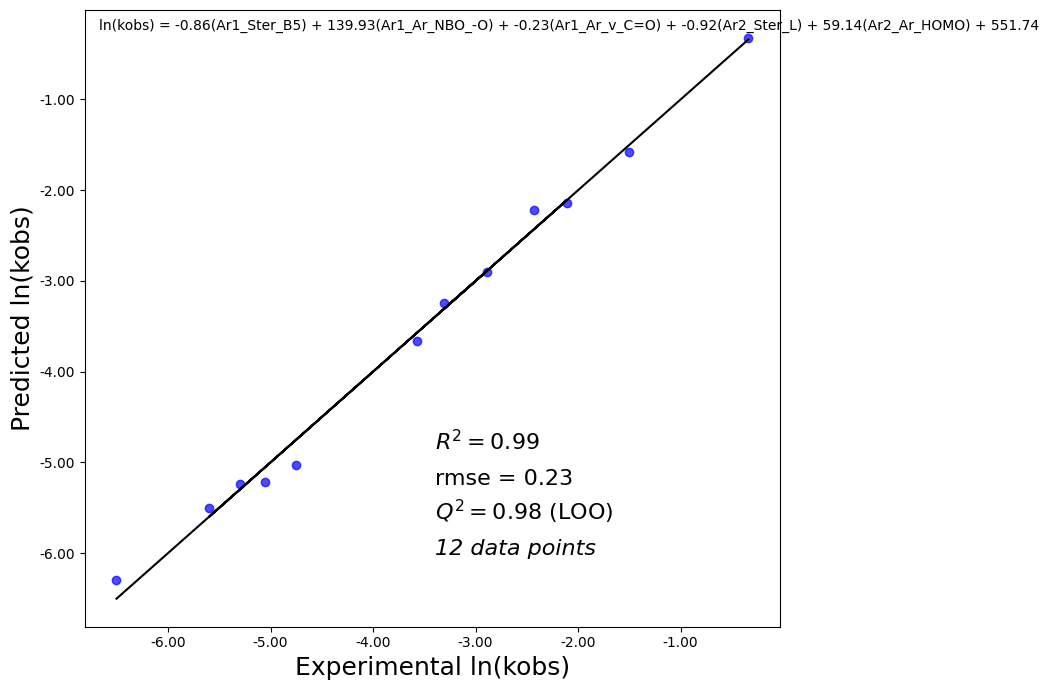


✅ Analysis complete!


In [5]:
# 指向原始資料（包含 Ar1、Ar2、...）
data_dir = "/content/DFTDescriptorPipeline/examples/indigo_diaryl"
xlsx_path = glob.glob(os.path.join(data_dir, "*.xlsx"))[0]
log_folder = os.path.join(data_dir, "logfiles")

# 一鍵執行
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,          # 直接用原檔
    target='ln(kobs)'
)